In [2]:
import os
import time
import numpy as np
import pandas as pd
import open3d as o3d
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import subprocess

# Paths to needed files
GT_PATH = "./dataset/ground_truth.csv"
MAP_PATH = "./dataset/map.pcd"
FRAMES_DIR = "./dataset/frames"
INIT_PATH = "./init_guess.txt"
# Path to compiled C++ NDT executable, needs the Point Cloud Library https://pointclouds.org/
NDT_EXECUTABLE = "C:/Users/marto/Documents/NDT/build/Desktop_Qt_6_10_0_MSVC2022_64bit-Debug/NDT.exe"  

# Parameters
VOXEL_SIZE = 0.5

# Load ground truth
ground_truth = pd.read_csv(GT_PATH)
ground_truth.columns = ground_truth.columns.str.strip()

# Estimate initial pose from ground truth of frame 0 and save it to a txt file so the NDT.exe can use it
gt_row = ground_truth.iloc[0]
gt_position = gt_row[["x", "y", "z"]].values
gt_orientation = gt_row[["roll", "pitch", "yaw"]].values
init_rot = Rotation.from_euler("xyz", gt_orientation).as_matrix()
init_transform = np.eye(4)
init_transform[:3, :3] = init_rot
init_transform[:3, 3] = gt_position
np.savetxt(INIT_PATH, init_transform, fmt="%.6f")

# variables to store results
estimated_positions = []
lateral_errors = []
yaw_errors = []
computation_times = []

# Frame loop
for frame_idx in range(len(ground_truth)):
    frame_file = os.path.join(FRAMES_DIR, f"frame_{frame_idx}.pcd")
    if not os.path.exists(frame_file):
        break

    # NDT will be done by a C++ executable
    start = time.time()
    result = subprocess.run(
        [NDT_EXECUTABLE, MAP_PATH, frame_file, INIT_PATH],
        capture_output=True, text=True
    )
    end = time.time()

    if result.returncode != 0:
        print(f"Error in NDT for frame {frame_idx}:", result.stderr)
        continue

    # Parse transformation matrix from the C++ console output
    lines = result.stdout.strip().split("\n")
    estimated_transform = np.array([
        [float(val) for val in line.split()] for line in lines
    ])

    estimated_position = estimated_transform[:3, 3]
    estimated_orientation = Rotation.from_matrix(estimated_transform[:3, :3]).as_euler("xyz")

    # Compute errors
    lateral_error = np.linalg.norm(estimated_position[:2] - gt_position[:2])
    yaw_error = abs(gt_orientation[2] - estimated_orientation[2])

    # Store results
    estimated_positions.append(estimated_position)
    lateral_errors.append(lateral_error)
    yaw_errors.append(np.degrees(yaw_error))
    computation_times.append(end - start)

    print(f"Frame {frame_idx}: Lateral Error = {lateral_error:.3f} m, Yaw Error = {np.degrees(yaw_error):.2f} deg, Time = {end - start:.2f} s")

Frame 0: Lateral Error = 0.046 m, Yaw Error = 0.20 deg, Time = 2.88 s
Frame 1: Lateral Error = 0.043 m, Yaw Error = 0.29 deg, Time = 3.17 s
Frame 2: Lateral Error = 0.046 m, Yaw Error = 0.25 deg, Time = 2.92 s
Frame 3: Lateral Error = 0.042 m, Yaw Error = 0.30 deg, Time = 2.93 s
Frame 4: Lateral Error = 0.043 m, Yaw Error = 0.34 deg, Time = 2.94 s
Frame 5: Lateral Error = 0.054 m, Yaw Error = 0.39 deg, Time = 2.95 s
Frame 6: Lateral Error = 0.052 m, Yaw Error = 0.28 deg, Time = 2.93 s
Frame 7: Lateral Error = 0.056 m, Yaw Error = 0.36 deg, Time = 2.97 s
Frame 8: Lateral Error = 0.045 m, Yaw Error = 0.25 deg, Time = 2.97 s
Frame 9: Lateral Error = 0.052 m, Yaw Error = 0.33 deg, Time = 2.93 s
Frame 10: Lateral Error = 0.053 m, Yaw Error = 0.29 deg, Time = 2.97 s
Frame 11: Lateral Error = 0.046 m, Yaw Error = 0.45 deg, Time = 2.96 s
Frame 12: Lateral Error = 0.049 m, Yaw Error = 0.25 deg, Time = 2.97 s
Frame 13: Lateral Error = 0.049 m, Yaw Error = 0.32 deg, Time = 2.93 s
Frame 14: Latera


Summary:
Mean Lateral Error: 0.078 m
Max Lateral Error: 0.100 m
Mean Computation Time per Frame: 2.749 s


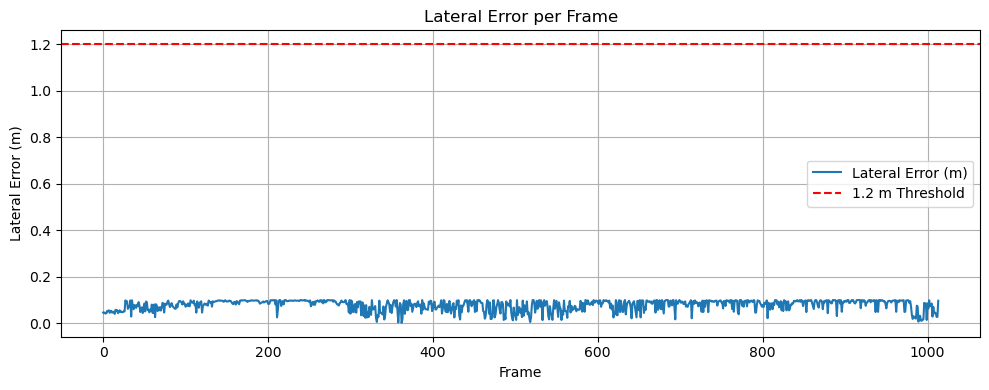

In [3]:
mean_lateral_error = np.mean(lateral_errors)
max_lateral_error = np.max(lateral_errors)
mean_time = np.mean(computation_times)

print("\nSummary:")
print(f"Mean Lateral Error: {mean_lateral_error:.3f} m")
print(f"Max Lateral Error: {max_lateral_error:.3f} m")
print(f"Mean Computation Time per Frame: {mean_time:.3f} s")

# Plot lateral errors
plt.figure(figsize=(10, 4))
plt.plot(lateral_errors, label="Lateral Error (m)")
plt.axhline(1.2, color='r', linestyle='--', label="1.2 m Threshold")
plt.title("Lateral Error per Frame")
plt.xlabel("Frame")
plt.ylabel("Lateral Error (m)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


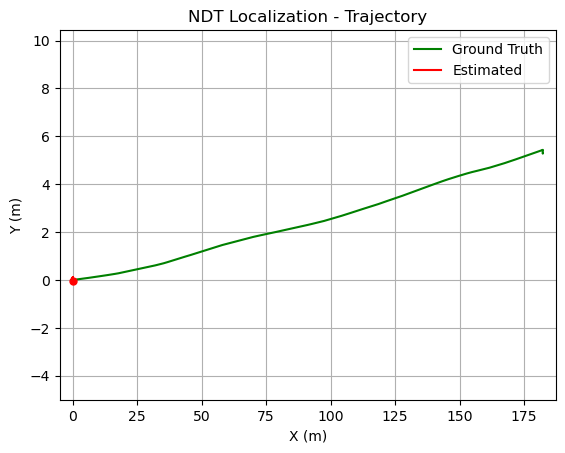

In [4]:
import matplotlib.animation as animation

ground_truth = pd.read_csv("./dataset/ground_truth.csv")
ground_truth.columns = ground_truth.columns.str.strip()
gt_xy = ground_truth[["x", "y"]].values

fig, ax = plt.subplots()
gt_line, = ax.plot([], [], 'g-', label="Ground Truth")
est_line, = ax.plot([], [], 'r-', label="Estimated")
vehicle_dot, = ax.plot([], [], 'ro', markersize=5)

ax.set_xlim(np.min(gt_xy[:, 0]) - 5, np.max(gt_xy[:, 0]) + 5)
ax.set_ylim(np.min(gt_xy[:, 1]) - 5, np.max(gt_xy[:, 1]) + 5)
ax.set_title("NDT Localization - Trajectory")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.legend()
ax.grid(True)

est_xy = np.array(estimated_positions)

def init():
    gt_line.set_data([], [])
    est_line.set_data([], [])
    vehicle_dot.set_data([], [])
    return gt_line, est_line, vehicle_dot

def update(frame):
    gt_line.set_data(gt_xy[:frame+1, 0], gt_xy[:frame+1, 1])
    est_line.set_data(est_xy[:frame+1, 0], est_xy[:frame+1, 1])
    vehicle_dot.set_data([est_xy[frame, 0]], [est_xy[frame, 1]])  # FIXED: wrap in list
    return gt_line, est_line, vehicle_dot

ani = animation.FuncAnimation(fig, update, frames=len(est_xy),
                              init_func=init, blit=True, interval=300)

ani.save("ndt_trajectory.mp4", writer='ffmpeg')